## Data Preprocessing

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [30]:
df = pd.read_csv('/kaggle/input/datasets/arnabnath8201/resume-jd/resume_jd_paired_v2.csv', engine='python', on_bad_lines='skip')
print(f"Data Loaded Successfully: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

Data Loaded Successfully: 9,700 rows, 4 columns

Columns: ['resume_text', 'job_description', 'match_score', 'match_label']


In [31]:
# random 5 rows
df.sample(5)

,resume_text,job_description,match_score,match_label
1663,Systems Automation Developer with 4 years work...,We are looking for a Site Reliability Engineer...,0.8112,high
3106,Senior Full Stack Web Developer bringing over ...,Seeking a skilled Senior iOS/Android Mobile De...,0.6590,medium
3910,Statistical Researcher with 2 years working ac...,We are looking for a Quantitative Analytics Ex...,0.5900,medium
4433,Quantitative Analytics Specialist bringing ove...,Seeking a skilled Deep Learning Systems Engine...,0.8025,medium
6989,Performance Marketing Specialist bringing over...,Seeking a skilled Distributed Systems Software...,0.3116,low


In [32]:
# dataset information
print("Dataset Info:")
print("=" * 60)
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9700 entries, 0 to 9699
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resume_text      9700 non-null   object 
 1   job_description  9700 non-null   object 
 2   match_score      9700 non-null   float64
 3   match_label      9700 non-null   object 
dtypes: float64(1), object(3)
memory usage: 303.3+ KB


In [33]:
# statistical summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,match_score
count,9700.000000
mean,0.611298
std,0.288898
min,0.000000
25%,0.371250
50%,0.726700
75%,0.850500
max,0.989400


In [34]:
print("\nText Columns Summary:")
df.describe(include='object')


Text Columns Summary:


,resume_text,job_description,match_label
count,9700,9700,9700
unique,8691,5178,3
top,TypeScript Core Developer bringing over 8 year...,Seeking a skilled Senior Data Scientist to joi...,medium
freq,4,32,3649


In [35]:
# Check for the missing values
print("Missing Values Analysis:")
print("=" * 60)
missing_vals = df.isnull().sum()
missing_pct = (missing_vals / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_vals,
    'Percentage': missing_pct
})

print(missing_df)
print(f"\nTotal missing values: {missing_vals.sum()}")

Missing Values Analysis:
                 Missing_Count  Percentage
resume_text                  0         0.0
job_description              0         0.0
match_score                  0         0.0
match_label                  0         0.0

Total missing values: 0


In [36]:
full_dupes = df.duplicated().sum()
print(f"Full duplicate rows: {full_dupes}")

Full duplicate rows: 0


In [37]:
print("\nDuplicate rows:")
df[df.duplicated(subset=['resume_text', 'job_description'], keep=False)]


Duplicate rows:


,resume_text,job_description,match_score,match_label
169,Culinary Kitchen Director bringing over 9 year...,Seeking a skilled Lead Quantitative Analytics ...,0.0874,low
175,Quantitative Analytics Specialist bringing ove...,Seeking a skilled MLOps Infrastructure Archite...,0.7486,medium
240,Server-Side Core Developer bringing over 11 ye...,Seeking a skilled Cloud Infrastructure Platfor...,0.8726,high
309,Backend and Web Architect bringing over 6 year...,Seeking a skilled Cross-Platform React Native ...,0.6914,medium
428,Performance Marketing Specialist bringing over...,Seeking a skilled Server-Side Developer to joi...,0.2531,low
...,...,...,...,...
9038,Performance Marketing Specialist bringing over...,Seeking a skilled Server-Side Developer to joi...,0.2489,low
9166,React Architect bringing over 3 years of indus...,Seeking a skilled MLOps Infrastructure Archite...,0.1930,low
9467,Infrastructure Platform Architect bringing ove...,Seeking a skilled Cloud IAM Compliance Special...,0.7373,medium
9590,CI/CD Automation Engineer bringing over 4 year...,Seeking a skilled Cloud IAM Compliance Special...,0.7063,medium


In [38]:
print(f"Total rows:          {len(df)}")
print(f"Unique resumes:      {df['resume_text'].nunique()}")
print(f"Unique JDs:          {df['job_description'].nunique()}")

print(f"Unique resume+JD pairs: {df[['resume_text','job_description']].drop_duplicates().shape[0]}")

Total rows:          9700
Unique resumes:      8691
Unique JDs:          5178
Unique resume+JD pairs: 9664


In [39]:
# find unique labels
print("Unique labels found:")
print(df['match_label'].value_counts())

print(f"\nExpected 3 labels, got: {df['match_label'].nunique()} unique values")
print("Distinct values:", df['match_label'].unique())

Unique labels found:
match_label
medium    3649
low       3157
high      2894
Name: count, dtype: int64

Expected 3 labels, got: 3 unique values
Distinct values: ['low' 'medium' 'high']


In [40]:
print("Score distribution:")
print(df['match_score'].describe())
print()

# Scores must be between 0.0 and 1.0 — flag the bad ones
match_score = df['match_score']
invalid_scores = df[
                    ( match_score < 0) | 
                    ( match_score > 1)
                    ]
print(f"Invalid scores (out of 0–1 range): {len(invalid_scores)}")
print(invalid_scores[['match_label', 'match_score']])

Score distribution:
count    9700.000000
mean        0.611298
std         0.288898
min         0.000000
25%         0.371250
50%         0.726700
75%         0.850500
max         0.989400
Name: match_score, dtype: float64

Invalid scores (out of 0–1 range): 0
Empty DataFrame
Columns: [match_label, match_score]
Index: []


In [41]:
print("Score stats per label (after lowercasing):")
df['match_label_lower'] = df['match_label'].str.lower()
print(df.groupby('match_label_lower')['match_score'].describe().round(2))

Score stats per label (after lowercasing):
                    count  mean   std  min   25%   50%   75%   max
match_label_lower                                                 
high               2894.0  0.86  0.12  0.0  0.86  0.89  0.92  0.99
low                3157.0  0.28  0.20  0.0  0.11  0.24  0.38  0.98
medium             3649.0  0.70  0.14  0.0  0.67  0.74  0.79  0.99


In [42]:
print("Missing values per column:")
print(df.isnull().sum())
print()

# Show the rows with nulls
nulls = df[df.isnull().any(axis=1)]
print(f"Rows with at least one null: {len(nulls)}")
nulls[['match_label', 'match_score']].head(10)

Missing values per column:
resume_text          0
job_description      0
match_score          0
match_label          0
match_label_lower    0
dtype: int64

Rows with at least one null: 0


,match_label,match_score


In [43]:
print("=" * 50)
print("DATA QUALITY REPORT — merged_dataset.csv")
print("=" * 50)
print(f"  Total rows:             {len(df)}")
print(f"  Full duplicates:        {df.duplicated().sum()}")
print(f"  Duplicate pairs:        {df.duplicated(subset=['resume_text','job_description']).sum()}")
print(f"  Null resume_text:       {df['resume_text'].isnull().sum()}")
print(f"  Null job_description:   {df['job_description'].isnull().sum()}")
print(f"  Label case variants:    {df['match_label'].nunique()} (expected 3)")
print(f"  Invalid scores (<0/>1): {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")
print("=" * 50)

DATA QUALITY REPORT — merged_dataset.csv
  Total rows:             9700
  Full duplicates:        0
  Duplicate pairs:        36
  Null resume_text:       0
  Null job_description:   0
  Label case variants:    3 (expected 3)
  Invalid scores (<0/>1): 0


## EDA

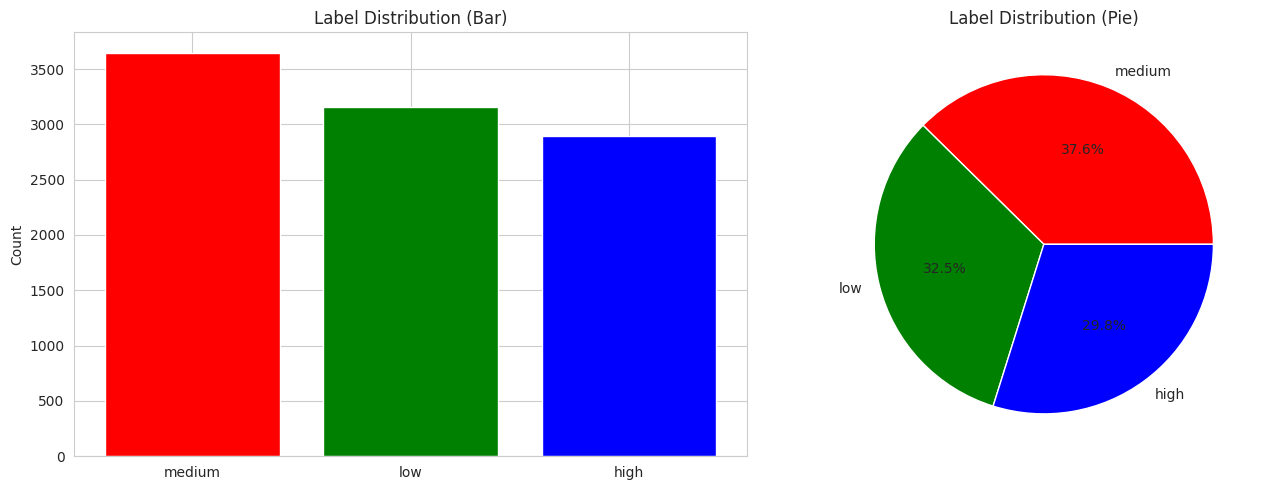

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['match_label'].str.lower().value_counts()

axes[0].bar(counts.index, counts.values, color=['red', 'green', 'blue'])
axes[0].set_title('Label Distribution (Bar)')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index,autopct='%1.1f%%', colors=['red', 'green', 'blue'])
axes[1].set_title('Label Distribution (Pie)')

plt.tight_layout()
plt.show()

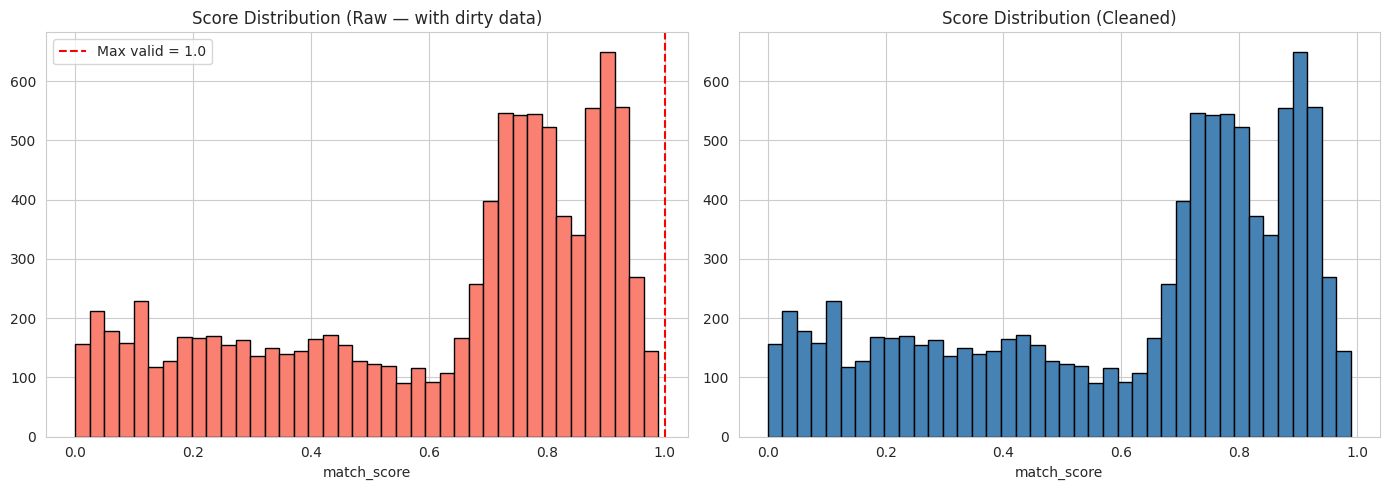

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning
axes[0].hist(df['match_score'], bins=40, color='salmon', edgecolor='black')
axes[0].set_title('Score Distribution (Raw — with dirty data)')
axes[0].set_xlabel('match_score')
axes[0].axvline(1.0, color='red', linestyle='--', label='Max valid = 1.0')
axes[0].legend()

# After cleaning
clean = df[(df['match_score'] >= 0) & (df['match_score'] <= 1)]
axes[1].hist(clean['match_score'], bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('Score Distribution (Cleaned)')
axes[1].set_xlabel('match_score')

plt.tight_layout()
plt.show()

## Make a copy of DataFrame

In [46]:
df_plot = df.copy()

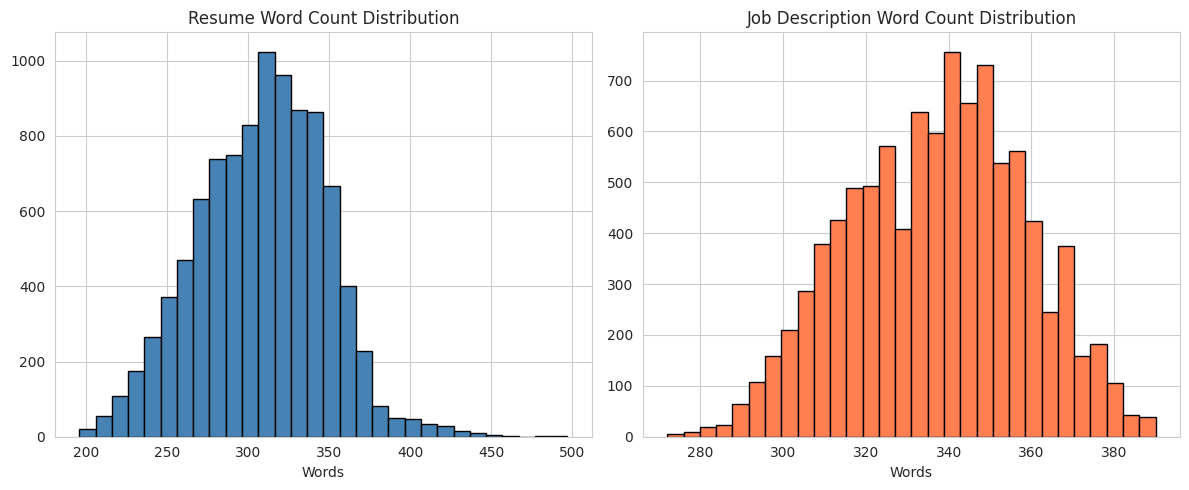

In [47]:
df_plot['resume_len'] = df_plot['resume_text'].str.lower().str.len()
df_plot['jd_len'] = df_plot['job_description'].str.lower().str.len()
 
fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].hist(df_plot['resume_len'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Resume Word Count Distribution')
axes[0].set_xlabel('Words')

axes[1].hist(df_plot['jd_len'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Job Description Word Count Distribution')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()

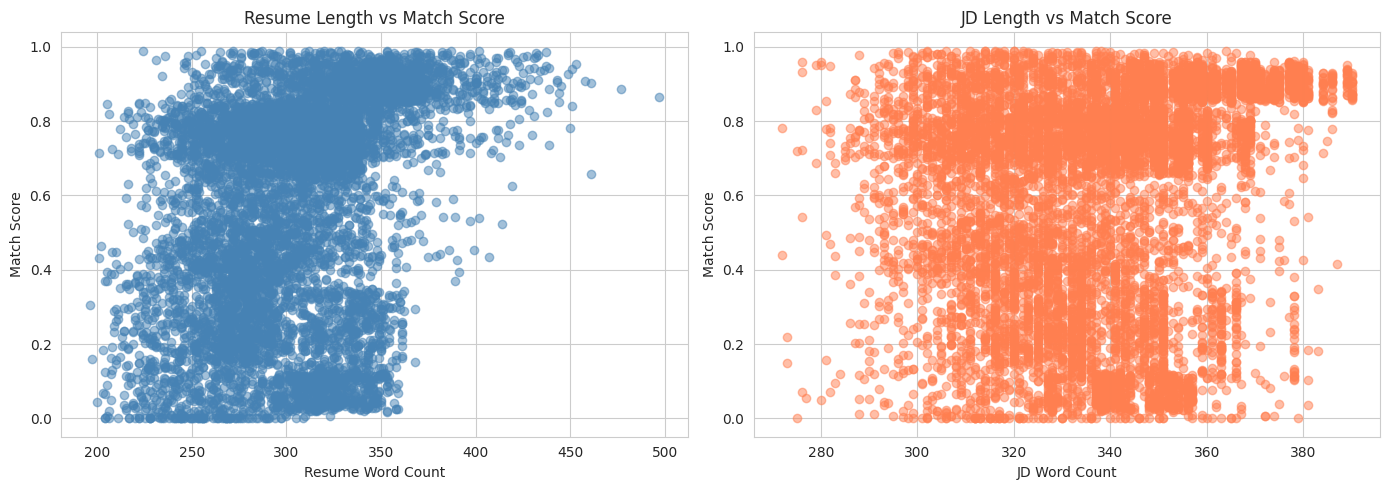

Resume length correlation: 0.414
JD length correlation:     0.193


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_plot['resume_len'], df_plot['match_score'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Resume Word Count')
axes[0].set_ylabel('Match Score')
axes[0].set_title('Resume Length vs Match Score')

axes[1].scatter(df_plot['jd_len'], df_plot['match_score'], alpha=0.5, color='coral')
axes[1].set_xlabel('JD Word Count')
axes[1].set_ylabel('Match Score')
axes[1].set_title('JD Length vs Match Score')

plt.tight_layout()
plt.show()

# Actual correlation values
print("Resume length correlation:", df_plot['resume_len'].corr(df_plot['match_score']).round(3))
print("JD length correlation:    ", df_plot['jd_len'].corr(df_plot['match_score']).round(3))


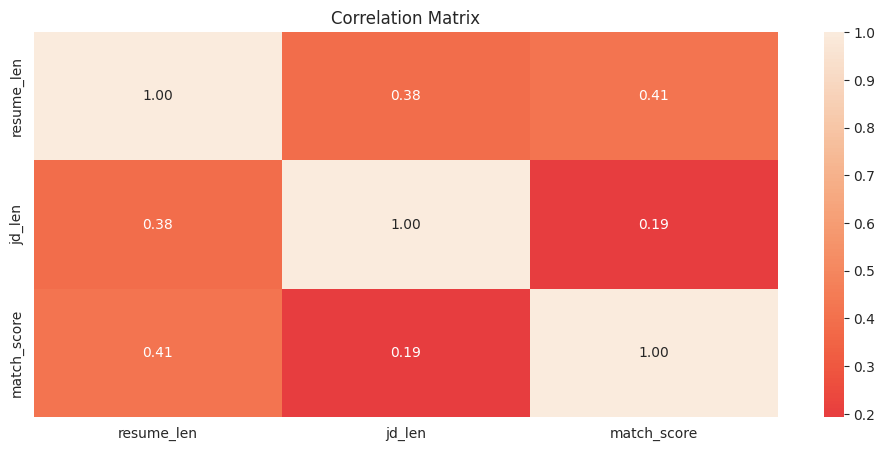

In [49]:
plt.figure(figsize=(12,5))
corr = df_plot[['resume_len', 'jd_len', 'match_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='rocket', center=0)
plt.title('Correlation Matrix')
plt.show()

In [50]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


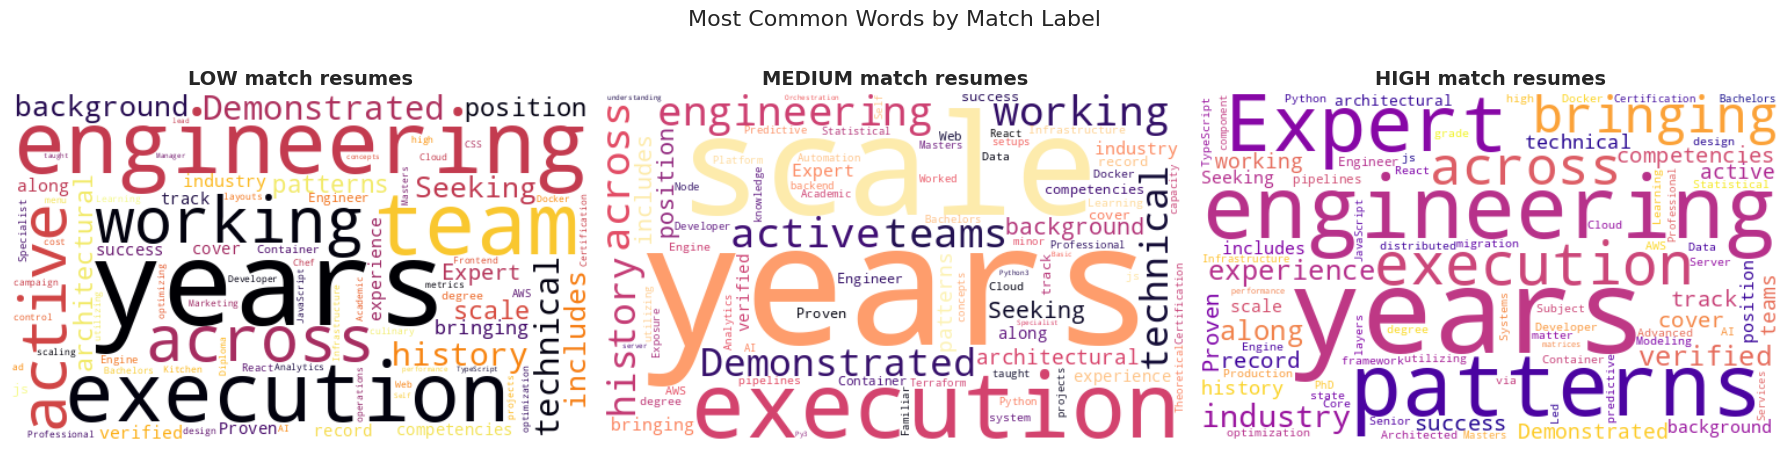

In [51]:
from wordcloud import WordCloud, STOPWORDS

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels  = ['low', 'medium', 'high']
colors = ['inferno', 'magma', 'plasma']

for ax, label, cmap in zip(axes, labels, colors):
    text = ' '.join(
        df_plot[df_plot['match_label'] == label]['resume_text'].dropna()
    )
    wc = WordCloud(
        height = 300, width = 500,
        background_color = 'white',
        colormap=cmap, max_words=80,
        stopwords=STOPWORDS,
        collocations=False
    ).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.upper()} match resumes', fontsize=14, fontweight='bold')

plt.suptitle('Most Common Words by Match Label', fontsize=16)
plt.tight_layout()
plt.show()

In [52]:
print("BEFORE CLEANING")
print("=" * 40)
print(f"Total rows:       {len(df)}")
print(f"Null resume_text: {df_plot['resume_text'].isnull().sum()}")
print(f"Null job_desc:    {df_plot['job_description'].isnull().sum()}")
print(f"Duplicates:       {df_plot.duplicated().sum()}")
print(f"Label variants:   {df_plot['match_label'].nunique()}")
print(f"Invalid scores:   {((df_plot['match_score'] < 0) | (df_plot['match_score'] > 1)).sum()}")

BEFORE CLEANING
Total rows:       9700
Null resume_text: 0
Null job_desc:    0
Duplicates:       0
Label variants:   3
Invalid scores:   0


In [53]:
# Scores must be in [0.0, 1.0], anything else is a data error
invalid_mask = (df_plot['match_score'] < 0.0) | (df_plot['match_score'] > 1.0)
print(f"Invalid scores found: {invalid_mask.sum()}")
print(df_plot[invalid_mask][['match_label','match_score']])

Invalid scores found: 0
Empty DataFrame
Columns: [match_label, match_score]
Index: []


In [54]:
#are the scores consistent with what the label claims?
# Expected: low=0.05-0.35, medium=0.40-0.70, high=0.75-0.95

print("Score range per label:")
print(df_plot.groupby('match_label')['match_score'].agg(['min','max','mean']).round(2))

# Flag any rows where label and score contradict each other
def label_score_mismatch(row):
    score = row['match_score']
    label = row['match_label']
    if label == 'high'   and score < 0.70: return True
    if label == 'medium' and (score < 0.35 or score > 0.75): return True
    if label == 'low'    and score > 0.40: return True
    return False

mismatches = df_plot.apply(label_score_mismatch, axis=1)
print(f"\nLabel-score mismatches: {mismatches.sum()}")
df_plot[mismatches][['match_label','match_score']]

Score range per label:
             min   max  mean
match_label                 
high         0.0  0.99  0.86
low          0.0  0.98  0.28
medium       0.0  0.99  0.70

Label-score mismatches: 2531


,match_label,match_score
2,medium,0.7782
3,medium,0.1982
4,medium,0.7591
13,medium,0.7611
14,low,0.6601
...,...,...
9675,medium,0.7649
9686,low,0.6094
9687,medium,0.7600
9692,medium,0.3392


In [55]:
# A 15-character resume or JD is useless for training
df_plot['resume_len'] = df_plot['resume_text'].str.split().str.len()
df_plot['jd_len']     = df_plot['job_description'].str.split().str.len()

print("Short texts found:")
print(f"  resume_text < 20 words: {(df_plot['resume_len'] < 20).sum()}")
print(f"  job_description < 10 words: {(df_plot['jd_len'] < 10).sum()}")

df_plot = df_plot[(df_plot['resume_len'] >= 20) & (df_plot['jd_len'] >= 10)]
print(f"\nRows after removing short texts: {len(df_plot)}")

Short texts found:
  resume_text < 20 words: 0
  job_description < 10 words: 0

Rows after removing short texts: 9700
